Find the time dependence of the following components: m_k computation, coupling integrals, bessel functions, A matrix population (aside from bessels, coupling), b-vector population, and linear solve.

The big O complexity can be reasoned from the equations/code, but getting the relative order of the corresponding coefficients is helpful when MEEM operates at scales where the cubic does not always dominate.

In [1]:
import sys
from pathlib import Path
HERE = Path.cwd().resolve()

dir_path_str = str((HERE / "..").resolve())
if dir_path_str not in sys.path:
  sys.path.insert(0, dir_path_str)

from multi_condensed import Problem
from matplotlib import pyplot as plt
import numpy as np
import time

import warnings
warnings.filterwarnings("ignore")

from matplotlib import cm
from matplotlib.colors import to_rgba, ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

In [2]:
# Modify Problem to return times for each of the relevant computations.

class TimedProblem(Problem):
    def __init__(self, h, d, a, heaving, NMK, m0, rho, scale = None):
        self.h = h
        self.d = d
        self.a = a
        self.heaving = heaving
        self.NMK = NMK
        self.m0 = m0
        self.rho = rho
        self.scale = a if scale is None else scale
        self.size = NMK[0] + NMK[-1] + 2 * sum(NMK[1:len(NMK) - 1])
        self.boundary_count = len(NMK) - 1
        self.time_dict = {"mk" : 0,
                          "coupling" : 0,
                          "bessels" : 0,
                          "a matrix" : 0,
                          "b vector" : 0,
                          "matrix solve": 0,
                          "hydros" : 0}
        start = time.perf_counter()
        self.m_k = self.m_k_array()
        end = time.perf_counter()
        self.N_k = self.N_k_array() # not timing this for simplicity, basic trig/exp
        self.time_dict["mk"] = end - start

    def timed_a_matrix(self):
        self.time_dict["bessels"] = 0 # reset to zero since these times accumulate from called functions in self.a_matrix

        t1 = time.perf_counter()
        _ = self.I_nm_vals() # this is calculated in self.a_matrix, reproduced here to avoid timing within that function
        _ = self.I_mk_vals()
        t2 = time.perf_counter()
        output = self.a_matrix()
        t3 = time.perf_counter()
        self.time_dict["coupling"] = t2 - t1
        self.time_dict["a matrix"] = (t3 - t2) - self.time_dict["bessels"] - self.time_dict["coupling"]
        return output
    
    def timed_b_vector(self):
        start = time.perf_counter()
        output = self.b_vector()
        end = time.perf_counter()
        self.time_dict["b vector"] = end - start
        return output
    
    def timed_get_unknown_coeffs(self, a, b):
        start = time.perf_counter()
        output = self.get_unknown_coeffs(a, b)
        end = time.perf_counter()
        self.time_dict["matrix solve"] = end - start
        return output
  
    ## Potential blocks
    # arguments: diagonal block on left (T/F), vectorized radial eigenfunction, boundary number
    def p_diagonal_block(self, left, radfunction, bd):
        h, d, a, NMK = self.h, self.d, self.a, self.NMK
        region = bd if left else (bd + 1)
        sign = 1 if left else (-1)
        start = time.perf_counter()
        diagonal = radfunction(list(range(NMK[region])), a[bd], region)
        end = time.perf_counter()
        self.time_dict["bessels"] += end - start
        return sign * (h - d[region]) * np.diag(diagonal)
    
    # arguments: dense block on left (T/F), vectorized radial eigenfunction, boundary number
    def p_dense_block(self, left, radfunction, bd, I_nm_vals):
        a, NMK = self.a, self.NMK
        I_nm_array = I_nm_vals[bd]
        if left: # determine which is region to work in and which is adjacent
            region, adj = bd, bd + 1
            sign = 1
            I_nm_array = np.transpose(I_nm_array)
        else:
            region, adj = bd + 1, bd
            sign = -1
        start = time.perf_counter()
        radial_vector = radfunction(list(range(NMK[region])), a[bd], region)
        end = time.perf_counter()
        self.time_dict["bessels"] += end - start
        radial_array = np.outer((np.full((NMK[adj]), 1)), radial_vector)
        return sign * radial_array * I_nm_array

    def p_dense_block_e(self, bd, I_mk_vals):
        a, NMK = self.a, self.NMK
        I_mk_array = I_mk_vals
        start = time.perf_counter()
        radial_vector = (np.vectorize(self.Lambda_k, otypes = [complex]))(list(range(NMK[bd+1])), a[bd])
        end = time.perf_counter()
        self.time_dict["bessels"] += end - start
        radial_array = np.outer((np.full((NMK[bd]), 1)), radial_vector)
        return (-1) * radial_array * I_mk_array

    ## Velocity blocks
    # arguments: diagonal block on left (T/F), vectorized radial eigenfunction, boundary number
    def v_diagonal_block(self, left, radfunction, bd):
        h, d, a, NMK = self.h, self.d, self.a, self.NMK
        region = bd if left else (bd + 1)
        sign = (-1) if left else (1)
        start = time.perf_counter()
        diagonal = radfunction(list(range(NMK[region])), a[bd], region)
        end = time.perf_counter()
        self.time_dict["bessels"] += end - start
        return sign * (h - d[region]) * np.diag(diagonal)

    # arguments: dense block on left (T/F), vectorized radial eigenfunction, boundary number
    def v_dense_block(self, left, radfunction, bd, I_nm_vals):
        a, NMK = self.a, self.NMK
        I_nm_array = I_nm_array = I_nm_vals[bd]
        if left: # determine which is region to work in and which is adjacent
            region, adj = bd, bd + 1
            sign = -1
            I_nm_array = np.transpose(I_nm_array)
        else:
            region, adj = bd + 1, bd
            sign = 1
        start = time.perf_counter()
        radial_vector = radfunction(list(range(NMK[region])), a[bd], region)
        end = time.perf_counter()
        self.time_dict["bessels"] += end - start
        radial_array = np.outer((np.full((NMK[adj]), 1)), radial_vector)
        return sign * radial_array * I_nm_array

    def v_diagonal_block_e(self, bd):
        h, a, NMK = self.h, self.a, self.NMK
        start = time.perf_counter()
        diagonal = (np.vectorize(self.diff_Lambda_k, otypes = [complex]))(list(range(NMK[bd+1])), a[bd])
        end = time.perf_counter()
        self.time_dict["bessels"] += end - start
        return h * np.diag(diagonal)

    def v_dense_block_e(self, radfunction, bd, I_mk_vals): # for region adjacent to e-type region
        I_km_array = np.transpose(I_mk_vals)
        a, NMK = self.a, self.NMK
        start = time.perf_counter()
        radial_vector = radfunction(list(range(NMK[bd])), a[bd], bd)
        end = time.perf_counter()
        self.time_dict["bessels"] += end - start
        radial_array = np.outer((np.full((NMK[bd + 1]), 1)), radial_vector)
        return (-1) * radial_array * I_km_array

    def timed_hydros(self, x, convention):
        start = time.perf_counter()
        am, dp = self.hydro_coeffs(x, convention)
        end = time.perf_counter()
        self.time_dict["hydros"] = end - start
        return am, dp

In [ ]:
# regions is body regions (total regions - 1)

# Vary regions and nmk, and plot according to expected dependence.
nmks = [10, 20, 30, 40, 50]
regions_lst = [10, 20, 30, 40, 50]

h = 100
m0 = 1
rho = 1023
runs = 10 # repeat each nmk/region + region pair to average out variation

keys = ["mk", "coupling", "bessels", "a matrix", "b vector", "matrix solve", "hydros"]

In [ ]:
configurations = []
for regions in regions_lst:
  d = [float(x) for x in np.linspace(5, 0.5, regions)]
  a = [float(x) for x in np.linspace(0.5, 5, regions)]
  heaving = [1] * regions
  for nmk in nmks:
    NMK = [nmk] * (regions + 1)
    config = {"nmk" : nmk,
              "regions" : regions}
    sum_dict = {key: 0 for key in keys}
    for i in range(runs):
      prob = TimedProblem(h, d, a, heaving, NMK, m0, rho)
      a_matrix = prob.timed_a_matrix()
      b_vector = prob.timed_b_vector()
      x = prob.timed_get_unknown_coeffs(a_matrix, b_vector)
      config["am"], config["dp"] = prob.timed_hydros(x, "capytaine")
      for key in keys:
        sum_dict[key] += prob.time_dict[key]
    for key in keys:
      config[key] = sum_dict[key] / runs
    print(regions, nmk)
    configurations.append(config)

10 10
10 20
10 30
10 40
10 50
20 10
20 20
20 30
20 40
20 50
30 10
30 20
30 30
30 40
30 50
40 10
40 20
40 30
40 40
40 50
50 10
50 20
50 30
50 40
50 50


In [5]:
# m_k computations (~ nmk)
# coupling integrals (~ nmk**2 * regions)
# bessel functions (~ nmk * regions)
# other a-matrix parts (~ (nmk * regions)**2)
# b-vector (~ nmk * regions, but most efficient would depend on # of heaving regions as well)
# matrix solve (~ (nmk * regions)**3)
# hydros

# configurations[0].keys()

In [6]:
def plot_dependence(configs, key, relater, xlab): # linear fit to relater
  xs = []
  ys = []
  for config in configs:
    xs.append(relater(config["nmk"], config["regions"]))
    ys.append(config[key])
  plt.scatter(xs, ys, color = "blue")
  coeffs = np.polyfit(xs, ys, deg=1)
  fit_fn = np.poly1d(coeffs)
  x_line = np.linspace(min(xs), max(xs), 100)
  slope, intercept = coeffs
  equation = f"y = {slope:.2e}x + {intercept:.2e}"
  plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes,
          fontsize=12, verticalalignment='top', color='red')
  plt.plot(x_line, fit_fn(x_line), color="red", label="Best-fit line")
  plt.xlabel(xlab)
  plt.ylabel("Time")
  plt.legend()
  plt.title(key + " computation")
  plt.show()
  return coeffs

def plot_dependence2(configs, key, relater, xlab): # quadratic fit, not used
  xs = []
  ys = []
  for config in configs:
    xs.append(relater(config["nmk"], config["regions"]))
    ys.append(config[key])
  plt.scatter(xs, ys, color = "blue")
  coeffs = np.polyfit(xs, ys, deg=2)
  fit_fn = np.poly1d(coeffs)
  x_line = np.linspace(min(xs), max(xs), 100)
  a, b, c = coeffs
  equation = f"y = {a:.2e}x² + {b:.2e}x + {c:.2e}"
  plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes,
           fontsize=12, verticalalignment='top', color='green')
  plt.plot(x_line, fit_fn(x_line), color="red", label="Best-fit line")
  plt.xlabel(xlab)
  plt.ylabel("Time")
  plt.legend()
  plt.title(key + " computation")
  plt.show()

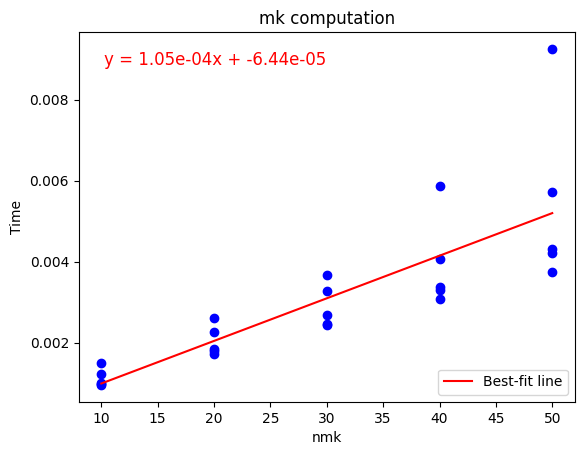

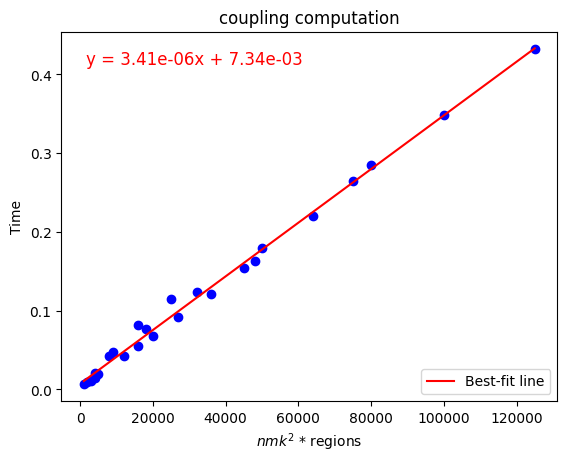

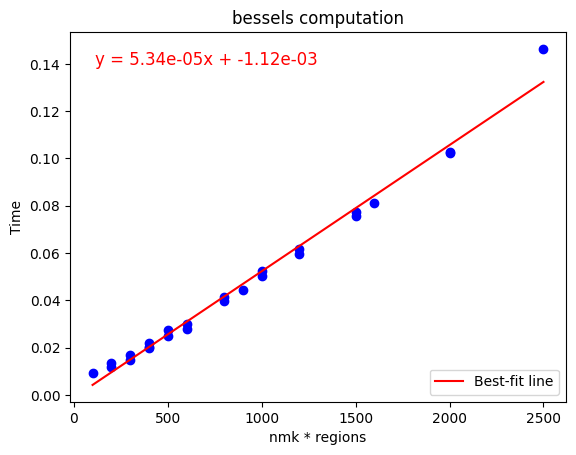

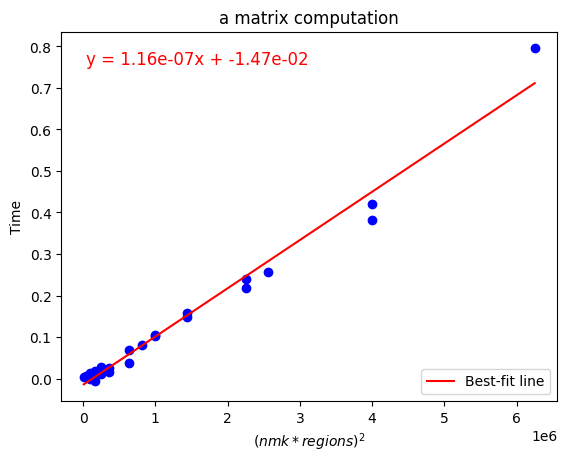

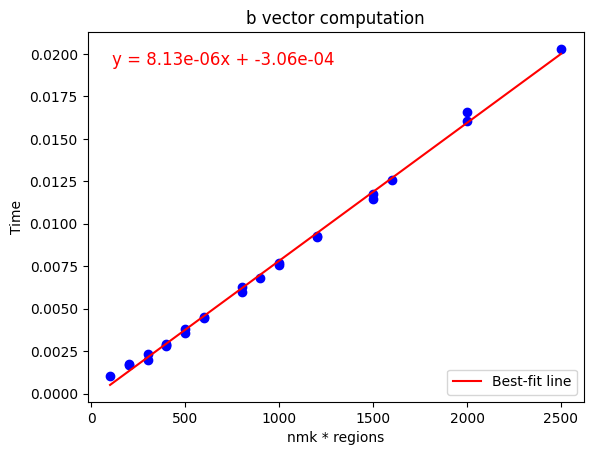

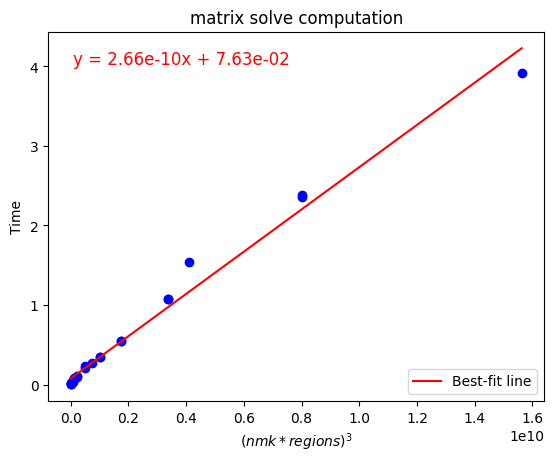

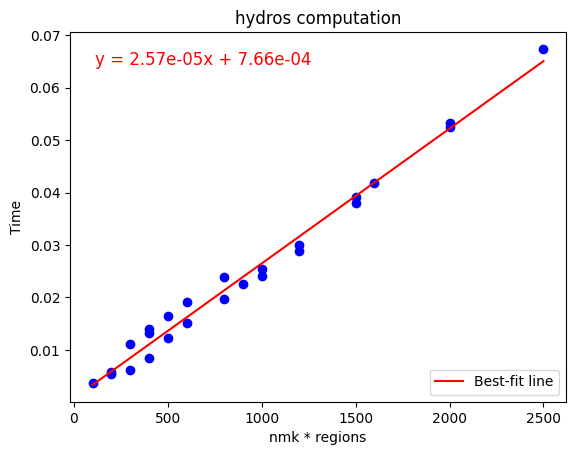

In [7]:
relation_dict = {"mk" : {"fcn" : lambda nmk, regions : nmk,
                         "label" : "nmk", "coeffs" : []},
                 "coupling" : {"fcn" : lambda nmk, regions : nmk**2 * regions,
                               "label" : "$nmk^2$ * regions", "coeffs" : []},
                 "bessels" : {"fcn" : lambda nmk, regions : nmk * regions,
                              "label" : "nmk * regions", "coeffs" : []},
                 "a matrix" : {"fcn" : lambda nmk, regions : (nmk * regions) ** 2,
                               "label" : "$(nmk * regions)^2$", "coeffs" : []},
                 "b vector" : {"fcn" : lambda nmk, regions : nmk * regions,
                               "label" : "nmk * regions", "coeffs" : []},
                 "matrix solve" : {"fcn" : lambda nmk, regions : (nmk * regions)**3,
                                   "label" : "$(nmk * regions)^3$", "coeffs" : []},
                 "hydros": {"fcn" : lambda nmk, regions : nmk * regions,
                            "label" : "nmk * regions", "coeffs" : []}}

for key in keys:
  relation_dict[key]["coeffs"] = plot_dependence(configurations, key, relation_dict[key]["fcn"], relation_dict[key]["label"])

In [ ]:
# # Dependencies where different regions have different nmk
# def meem_computation_time(NMK):
#   unknown_coeffs = NMK[0] + 2 * sum(NMK[1:-1]) + NMK[-1]
#   t1 = 7.6e-5 * NMK[-1]
#   t2 = 3.7e-6 * sum([NMK[i] * NMK[i+1] for i in range(len(NMK) - 1)])
#   t3 = 4.9e-5 * unknown_coeffs
#   t4 = 5.4e-8 * (unknown_coeffs)**2
#   t5 = 8.0e-6 * unknown_coeffs
#   t6 = 5.3e-10 * (unknown_coeffs)**3
#   t7 = 2.6e-5 * unknown_coeffs
#   return sum([t1, t2, t3, t4, t5, t6, t7])

In [ ]:
def times(nmk, regions):
  return {key : relation_dict[key]["fcn"](nmk, regions) * relation_dict[key]["coeffs"][0] for key in keys}

def get_times(nmks, regions_lst):
  runtime_surfaces = {key: np.zeros((len(regions_lst), len(nmks))) for key in keys}
  for j, regions in enumerate(regions_lst):
    for i, nmk in enumerate(nmks):
      result = times(nmk, regions)
      for key in keys:
        runtime_surfaces[key][j, i] = result[key]
  return runtime_surfaces

def plot_3D(nmks, regions_lst):
  X, Y = np.meshgrid(nmks, regions_lst)
  runtime_surfaces = get_times(nmks, regions_lst)
  fig = plt.figure(figsize=(10, 7))
  ax = fig.add_subplot(111, projection='3d')

  cmap = plt.get_cmap("tab10")
  colors = [to_rgba(cmap(i), alpha=0.6) for i in range(len(runtime_surfaces))]

  for (name, Z), color in zip(runtime_surfaces.items(), colors):
      ax.plot_surface(X, Y, Z, alpha=0.6, label=name, color=color)
      ax.plot([], [], label=name, color=color)  # legend workaround

  ax.set_xlabel("nmk/region")
  ax.set_ylabel("regions")
  ax.set_zlabel("Runtime")
  ax.set_title("Function Runtimes over nmk/region and regions")
  ax.legend()
  plt.tight_layout()
  plt.show()

def plot_times_contour(nmks, regions_lst, keys, key_colors, exclude = []):
  X, Y = np.meshgrid(nmks, regions_lst)
  keys = keys.copy()
  for key in exclude:
      keys.remove(key)

  func_to_int = {key: i for i, key in enumerate(keys)}

  labels = np.zeros((len(regions_lst), len(nmks)), dtype = int)

  for j, regions in enumerate(regions_lst):
    for i, nmk in enumerate(nmks):
        result = times(nmk, regions)
        for key in exclude:
          del result[key]
        # get the function with the maximum (slowest) runtime
        slowest_func = max(result, key=result.get)
        labels[j, i] = func_to_int[slowest_func]

  plt.figure(figsize=(6, 6), constrained_layout=True)
  colors_in_order = [key_colors[key] for key in keys]
  cmap = ListedColormap(colors_in_order)
  norm = BoundaryNorm(np.arange(-0.5, len(colors_in_order)+0.5), len(colors_in_order))
  im = plt.imshow(labels, cmap=cmap, norm = norm, origin='lower', extent=[
    nmks[0] - 0.5, nmks[-1] + 0.5, regions_lst[0] - 0.5, regions_lst[-1] + 0.5], interpolation='none')
  plt.xlabel("terms per region")
  plt.ylabel("region count")
  plt.title("Dominating function at each (terms/region, regions)")

  # Manual legend using patches
  legend_handles = [Patch(color = key_colors[key], label=key) for key in keys]
  # plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left')

  # plt.tight_layout()
  plt.show()

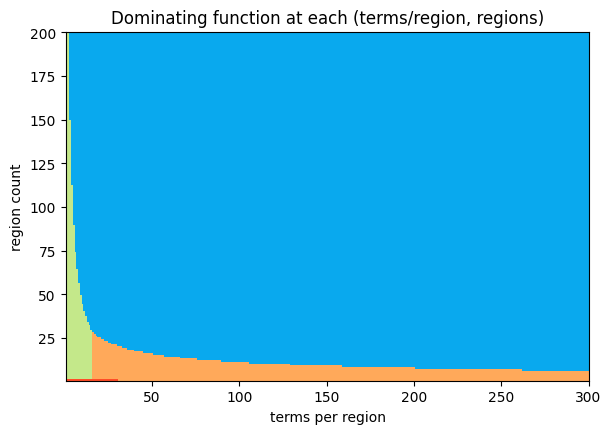

In [10]:
cmap = cm.get_cmap("rainbow") #gnuplot
key_colors = {key: cmap(1 - (0.1 + 0.8 * i / (len(keys) - 1))) for i, key in enumerate(keys)}
nmks = list(range(1, 301))
regions_lst = list(range(1, 201))
plot_times_contour(nmks, regions_lst, keys, key_colors)
# plot_times_contour(nmks, regions_lst, keys, key_colors, exclude = ["mk"])
# plot_times_contour(nmks, regions_lst, keys, key_colors, exclude = ["matrix solve"])
# plot_times_contour(nmks, regions_lst, keys, key_colors, exclude = ["matrix solve", "mk", "coupling"])

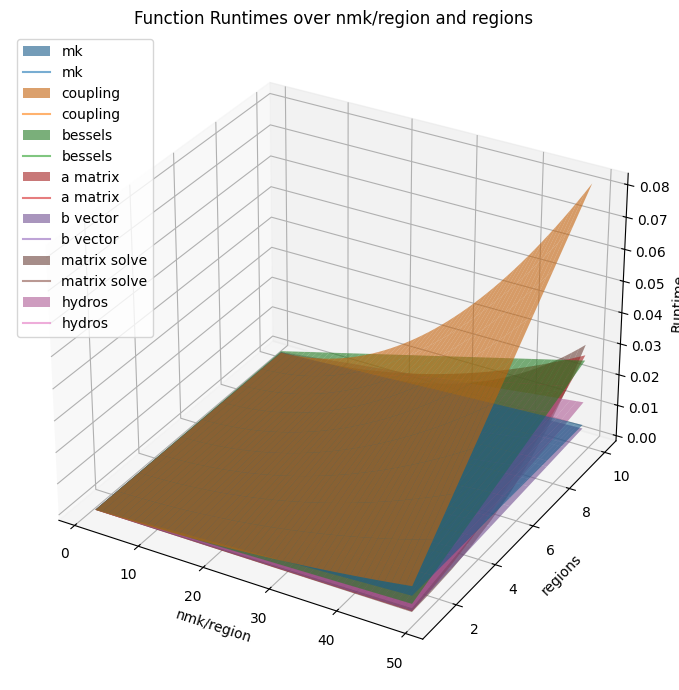

In [11]:
plot_3D(list(range(1, 50)), list(range(1, 11)))

In [14]:
# RM3 bar chart
# Vary regions and nmk, and plot according to expected dependence.
base_nmk = [63, 84, 42]
meem_mults = [0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2]

h = 100
m0 = 0.1
rho = 1023
runs = 10
heaving = [0, 1]

rm3_configs = []

for mult in meem_mults:
  NMK = [int(np.ceil(entry * mult)) for entry in base_nmk]
  config = {"NMK" : NMK}
  sum_dict = {key: 0 for key in keys}
  for i in range(runs):
    prob = TimedProblem(h, d, a, heaving, NMK, m0, rho)
    a_matrix = prob.timed_a_matrix()
    b_vector = prob.timed_b_vector()
    x = prob.timed_get_unknown_coeffs(a_matrix, b_vector)
    config["am"], config["dp"] = prob.timed_hydros(x, "capytaine")
    for key in keys:
      sum_dict[key] += prob.time_dict[key]
  for key in keys:
    config[key] = sum_dict[key] / runs
  print(NMK)
  rm3_configs.append(config)

[13, 17, 9]
[26, 34, 17]
[38, 51, 26]
[51, 68, 34]
[63, 84, 42]
[76, 101, 51]
[89, 118, 59]
[101, 135, 68]
[114, 152, 76]
[126, 168, 84]


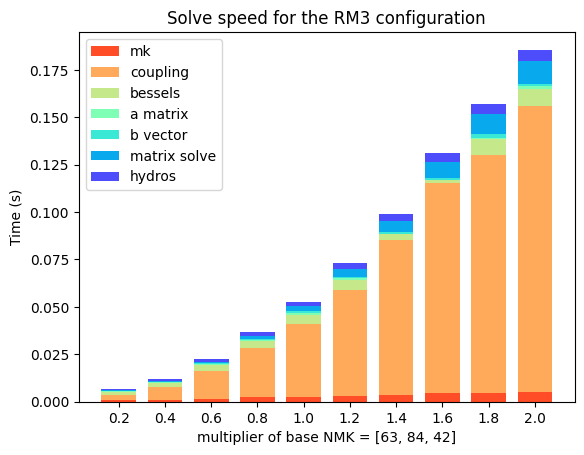

In [15]:
def bar_chart(data, keys, key_colors):
  x = meem_mults
  bottom = np.zeros(len(data))
  for k in keys:
    heights = np.array([record.get(k, 0) for record in data])
    plt.bar(x, heights, bottom=bottom, width= 0.15, color=key_colors[k], label=k)
    bottom += heights

  plt.xticks(x)
  plt.xlabel("multiplier of base NMK = [63, 84, 42]")
  plt.ylabel("Time (s)")
  plt.title("Solve speed for the RM3 configuration")
  plt.legend()
  plt.show()

bar_chart(rm3_configs, keys, key_colors)